In [57]:
import numpy as np
import pandas as pd
from pretty_confusion_matrix import pp_matrix
import datetime
import time
# from skimage import transform
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F
# from random_split import SingleImgDataset

### Read Database

In [58]:
import numpy as np
import traceback
import time

def read_database(path):
    #print("Start reading data from csv file")
    dataset = []

    try:
        data = np.loadtxt(path, delimiter=",", skiprows=2)
    except:
        print("Path not found:", path)
        raise

    # Extract total number of frames from the data
    max_frame = int(np.max(data[:, 0]))  # highest frame number in the data
    framelength = 80  # max number of frames
    pointlength = 80  # max number of objects per frame

    # We want to right-align the data, so pad zeros at the beginning
    start_frame = framelength - max_frame  # zero padding at beginning

    # Initialize zero-padded gesture array
    gesturedata = np.zeros((framelength, 4, 2))  # (frames, features, top-2 objects)
    counter = 0
    datalength = len(data)

    FrameNumber = 1

    while counter < datalength and FrameNumber <= max_frame:
        velocity = np.zeros(pointlength)
        peak_val = np.zeros(pointlength)
        x_pos = np.zeros(pointlength)
        y_pos = np.zeros(pointlength)
        iterator = 0

        try:
            while counter < datalength and data[counter][0] == FrameNumber:
                velocity[iterator] = data[counter][3]
                peak_val[iterator] = data[counter][4]
                x_pos[iterator] = data[counter][5]
                y_pos[iterator] = data[counter][6]
                iterator += 1
                counter += 1
        except Exception as e:
            print("Error while parsing frame:", FrameNumber)
            traceback.print_exc()

        # Take top-2 objects with highest peak_val
        top_idx = np.argsort(peak_val[:iterator])[::-1][:2]
        framedata = np.array([
            velocity[top_idx],
            peak_val[top_idx],
            x_pos[top_idx],
            y_pos[top_idx]
        ])  # shape (4, 2)

        try:
            gesturedata[start_frame + FrameNumber - 1] = framedata
        except IndexError:
            print("Frame number out of bounds:", FrameNumber)
            break

        FrameNumber += 1

    # Add to dataset
    dataset.append(gesturedata)

    # print("End of the loop")
    return dataset

In [59]:
# import numpy as np
# import traceback
# import time
# path ='data/data split person - 1/train/hand_to_left/gesture_101.csv'
# dataset = []

# try:
#     data = np.loadtxt(path, delimiter=",", skiprows=2) #skip header and null point
# except:
#     print("Path not found: "+path)
#     # break

# FrameNumber = 1#int(80-data[-1][0]+1) # 1 <==================== zero padding at the beginning
# # FrameNumber = int((80-data[-1][0])/2+1) # 1 <==================== zero padding both sides
# FrameCounter = 1
# pointlenght = 80 #maximum number of points in array
# framelenght = 80 #maximum number of frames in arrat
# datalenght = int(len(data))
# gesturedata = np.zeros((framelenght,4,2))
# counter = 0

# while counter < datalenght:
#     velocity = np.zeros(pointlenght)
#     peak_val = np.zeros(pointlenght)
#     x_pos = np.zeros(pointlenght)
#     y_pos = np.zeros(pointlenght)
#     iterator = 0

#     try:
#         while data[counter][0] == FrameNumber:
#             velocity[iterator] = data[counter][3]
#             peak_val[iterator] = data[counter][4]
#             x_pos[iterator] = data[counter][5]
#             y_pos[iterator] = data[counter][6]
#             iterator += 1
#             counter += 1
#     except:
#         pass
#         # print(" ")
#     # index = np.argmax(peak_val)
#     index = np.argsort(peak_val)[::-1][:2] #<========================= sort peak values
#     framedata = np.array([velocity[index], peak_val[index],x_pos[index],y_pos[index]])
#     try:
#         # gesturedata[FrameNumber - 1] = framedata #<========================= if more than one identical max
#         gesturedata[FrameNumber - 1] = framedata.reshape(4, 2)
#     except:
#         print("Frame number out of bound", FrameNumber)
#         break

#     FrameNumber += 1
#     FrameCounter += 1

#     dataset.append(gesturedata)
#     print(dataset.__len__(), "frames added")
# print("End of the loop")
# print(dataset[1].shape)


In [60]:
# import numpy as np
# import traceback

# path = 'data/data split person - 1/train/hand_to_left/gesture_101.csv'
# dataset = []

# try:
#     data = np.loadtxt(path, delimiter=",", skiprows=2)
# except:
#     print("Path not found:", path)
#     raise

# # Extract total number of frames from the data
# max_frame = int(np.max(data[:, 0]))  # highest frame number in the data
# framelength = 80  # max number of frames
# pointlength = 80  # max number of objects per frame

# # We want to right-align the data, so pad zeros at the beginning
# start_frame = framelength - max_frame  # zero padding at beginning

# # Initialize zero-padded gesture array
# gesturedata = np.zeros((framelength, 4, 2))  # (frames, features, top-2 objects)
# counter = 0
# datalength = len(data)

# FrameNumber = 1

# while counter < datalength and FrameNumber <= max_frame:
#     velocity = np.zeros(pointlength)
#     peak_val = np.zeros(pointlength)
#     x_pos = np.zeros(pointlength)
#     y_pos = np.zeros(pointlength)
#     iterator = 0

#     try:
#         while counter < datalength and data[counter][0] == FrameNumber:
#             velocity[iterator] = data[counter][3]
#             peak_val[iterator] = data[counter][4]
#             x_pos[iterator] = data[counter][5]
#             y_pos[iterator] = data[counter][6]
#             iterator += 1
#             counter += 1
#     except Exception as e:
#         print("Error while parsing frame:", FrameNumber)
#         traceback.print_exc()

#     # Take top-2 objects with highest peak_val
#     top_idx = np.argsort(peak_val[:iterator])[::-1][:2]
#     framedata = np.array([
#         velocity[top_idx],
#         peak_val[top_idx],
#         x_pos[top_idx],
#         y_pos[top_idx]
#     ])  # shape (4, 2)

#     try:
#         gesturedata[start_frame + FrameNumber - 1] = framedata
#     except IndexError:
#         print("Frame number out of bounds:", FrameNumber)
#         break

#     FrameNumber += 1

# # Add to dataset
# dataset.append(gesturedata)

# # print("End of the loop")
# # print("Total frames in dataset:", len(dataset))
# # print("Shape of one gesture sample:", dataset[0].shape)

In [61]:
import numpy
print(numpy.__version__)

1.26.4


In [62]:
import sys
print(sys.executable)

/home/bhanuiit/anaconda3/envs/radar/bin/python


### Random Split

In [63]:
import numpy as np
import glob
import torch.utils.data
import os
import math
# from skimage import io, transform
from PIL import Image
import torch
import torchvision as vision
from torchvision import transforms, datasets
import random
# from read_gestures_np import read_database

class SingleImgDataset(torch.utils.data.Dataset):

    def __init__(self, root_dir, test_mode=False, shuffle = True, num_models=0):
        self.classnames=["hand_to_left", "hand_to_right", "hand_closer", "hand_away"]
        self.root_dir = root_dir
        
        self.test_mode = test_mode

        # set_ = root_dir.split('/')[-1]
        # parent_dir = root_dir.rsplit('/',2)[0]
        self.filepaths = []
        
        for i in range(len(self.classnames)):
            all_files = sorted(glob.glob(root_dir+'/'+self.classnames[i]+'/gesture*.csv'))
            if num_models == 0:
                # Use the whole dataset
                self.filepaths.extend(all_files)
            else:
                self.filepaths.extend(all_files[:min(num_models,len(all_files))])

        self.transform = transforms.Compose([
            # transforms.RandomHorizontalFlip(), # this is not allowed for gesture dataset as flipping would reslut in wrong gestures
            transforms.ToTensor(),
            transforms.Normalize(mean=0.0348,std=0.1760)
        ])


    def __len__(self):
        return len(self.filepaths)


    def __getitem__(self, idx):
        path = self.filepaths[idx]
        class_name = path.split('/')[-2]
        class_id = self.classnames.index(class_name)
        a = read_database(path)
        b = a[0][:,[0,2,3],:]
        b =  self.transform(b)
        return (class_id, path, b.float())
        

In [64]:
seed = 42

# device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [65]:
# Hyper-parameters
hidden_size = 16
num_classes = 4
num_epochs = 100
batch_size = 16
learning_rate = 0.001

# for RNN
input_size = 3*2 # 160 # 2*80 :  2 features (x,y) per target (total 80 targets per frame)
sequence_length = 80 # Total number of frames in a file after zero padding
num_layers = 2 # Number of stacked LSTM layers


In [66]:
# Cross Validation Fold Selection
split = 1 # person Split - val: Person 1

train_path = "data/data split person - "+str(split)+"/train"
test_path = "data/data split person - "+str(split)+"/test"

# Load Train dataset
train_dataset = SingleImgDataset(train_path)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, num_workers=0)

'''
## Calculate the mean and std of the training dataset for normalization
'''

# Load Test dataset
test_dataset = SingleImgDataset(test_path)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, num_workers=0)

In [67]:
# LSTM Network

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, dropout = 0.5, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # Set initial hidden states
        h0 = torch.randn(self.num_layers, x.size(0), self.hidden_size).to(device).requires_grad_()
        # Set initial cell states
        c0 = torch.randn(self.num_layers, x.size(0), self.hidden_size).to(device).requires_grad_()

        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0.detach(), c0.detach()))  
        
        # We need the last times step's o/p for classification (tghrough a fully connected layer)
        out = self.fc(out[:, -1, :])  # out.size() = (batch_size, num_classes)
        return out
    

In [68]:
# Initialize the model, loss function and optimizer
model = RNN(input_size, hidden_size, num_layers, num_classes).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

epoch: 1/100, step 1/57, loss: 1.3209
epoch: 1/100, step 2/57, loss: 1.3103
epoch: 1/100, step 3/57, loss: 1.3056
epoch: 1/100, step 4/57, loss: 1.2929
epoch: 1/100, step 5/57, loss: 1.2883
epoch: 1/100, step 6/57, loss: 1.2710
epoch: 1/100, step 7/57, loss: 1.2478
epoch: 1/100, step 8/57, loss: 1.2364
epoch: 1/100, step 9/57, loss: 1.2197
epoch: 1/100, step 10/57, loss: 1.2050
epoch: 1/100, step 11/57, loss: 1.1963
epoch: 1/100, step 12/57, loss: 1.1822
epoch: 1/100, step 13/57, loss: 1.3570
epoch: 1/100, step 14/57, loss: 1.5482
epoch: 1/100, step 15/57, loss: 1.5448
epoch: 1/100, step 16/57, loss: 1.5526
epoch: 1/100, step 17/57, loss: 1.5361
epoch: 1/100, step 18/57, loss: 1.5359
epoch: 1/100, step 19/57, loss: 1.5288
epoch: 1/100, step 20/57, loss: 1.5367
epoch: 1/100, step 21/57, loss: 1.5247
epoch: 1/100, step 22/57, loss: 1.5219
epoch: 1/100, step 23/57, loss: 1.5048
epoch: 1/100, step 24/57, loss: 1.4899
epoch: 1/100, step 25/57, loss: 1.4886
epoch: 1/100, step 26/57, loss: 1.

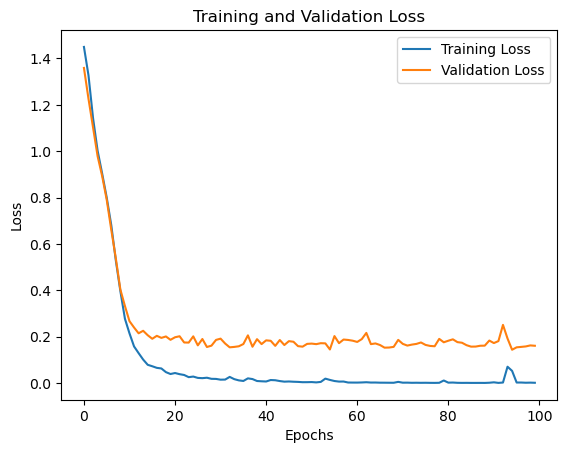

Elasped time: 121.41757011413574


In [69]:
# Train the model
trainingEpoch_loss = []
validationEpoch_loss = []

n_total_step = len(train_loader) # i.e. total 600 batches (100 per batch)

start = time.time()

for epoch in range(num_epochs):# num_epochs =2
    step_loss =[]
    validationStep_loss =[]
    model.train()  # Set the model to training mode

    for i, (labels, paths, images) in enumerate(train_loader):
        images = images.reshape(-1, sequence_length, input_size).requires_grad_().to(device)  # Reshape to (batch_size, sequence_length, input_size)
        labels = labels.to(device)
        # Forward pass
        outputs = model(images)
        training_loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        training_loss.backward()
        optimizer.step()
        step_loss.append(training_loss.item())

        if (i+1)%1 ==0:
            print(f'epoch: {epoch+1}/{num_epochs}, step {i+1}/{n_total_step}, loss: {training_loss.item():.4f}')
        
    trainingEpoch_loss.append(np.array(step_loss).mean())

    with torch.no_grad():
        model.eval()
        # validationEpoch_loss = []

        for (labels, paths, images) in test_loader:
            images = images.reshape(-1, sequence_length, input_size).requires_grad_().to(device)
            labels = labels.to(device)
            outputs = model(images)
            validation_loss = criterion(outputs, labels)
            validationStep_loss.append(validation_loss.item())
    validationEpoch_loss.append(np.array(validationStep_loss).mean())

plt.plot(trainingEpoch_loss, label='Training Loss')
plt.plot(validationEpoch_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Calculate the training time
end = time.time()
print('Elasped time:', end - start)


In [70]:
# Test and Evaluate the model

nb_classes = 4
confusion_matrix = torch.zeros(nb_classes, nb_classes)

with torch.no_grad():
    n_correct = 0
    n_samples = 0

    for (labels, paths, images) in test_loader:
        images = images.reshape(-1, sequence_length, input_size).requires_grad_().to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        n_samples += labels.shape[0]
        n_correct += (predicted == labels).sum().item()

        for t, p in zip(labels.view(-1), predicted.view(-1)):
            confusion_matrix[t.long(), p.long()] += 1
    
    print(confusion_matrix)

    acc = 100.0 * n_correct / n_samples
    print(f'Accuracy of the model on the test data: {acc} %')


                         


Frame number out of bounds: 1
tensor([[ 96.,   2.,   2.,   0.],
        [  1.,  99.,   0.,   0.],
        [  0.,   0., 100.,   0.],
        [  1.,   9.,   2., 188.]])
Accuracy of the model on the test data: 96.6 %
